# long generations num_generation ablation

some back of the envelope calcs for cost of these experiments

* old experiments (200 samples, 10 generations)
    * entailment predictions 2546
    * of those hashed 855 
    * total gpt-4 queries: 2546 - 855 = 1691
    * number of datapoints: 200
    * (queries for 400 datapoints: 3382)
    * total cost: 10
    * cost per prediction: 10/1691


* new epxeriments interim (400 samples (running still), 15 generations)
    * entailment predictions: 1179
    * of those hashed: 704
    * total gpt-4 queries:  1179 - 704 = 475
    * number of datapoints so far: 28
    * expected gpt-4 queries over 400 examples: 6785
    * expected total cost: 10/1691*6785 = 40


* cost on squad (still running, 15 generations)
    * entailment predictions: 29394
    * of those hashed: 5216
    * total gpt-4 queries: 24178
    * number of datapoints so far: 294
    * expected gpt-4 queries for 400 examples: 32895
    * expected total cost: 10/1691 * 32895 = 200



* how to compute
    * entailment predictions: `grep -i 'prediction' *168315* | wc`
    * of those hashed: `grep -i 'hashed' *168315* | wc`
    * total gpt-4 queries: `entailment predictions` - `of those hashed`
    * number of datapoints so far: `grep -i 'new item' *168315*`
    * expected gpt-4 queries for 400 examples: `total gpt-4 queries` / `number of datapoints so far` * 400
    * expected total cost: 10/1691 * `expected gpt-4 queries`






In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir('..')
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np


from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'goatml'

In [2]:
# export to eval file
def get_vals(x):
    return x['mean'], x['mean']-x['bootstrap']['std_err'], x['mean']+x['bootstrap']['std_err']
    # return x['mean'], x['bootstrap']['low'], x['bootstrap']['high']

def get_vals2(x):
    return x['means'], x['low'], x['high']


def get_perfs(metrics):
    data = []
    for method in metrics['performance']:
        mean, low, high = get_vals(metrics['performance'][method])
        data.append([method, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'means', 'low', 'high'])
    return df.set_index('method')

def plot_bar(df, color='C0', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    df.plot.bar(y='means', yerr=[df.means - df.low, df.high - df.means], color=color, ax=ax)

def get_uncertainty_df(metrics):
    data = []
    for method in metrics['uncertainty']:
        for metric in metrics['uncertainty'][method]:
            mean, low, high = get_vals(metrics['uncertainty'][method][metric])
            data.append([method, metric, mean, low, high])
    
    df = pd.DataFrame(data, columns=['method', 'metric', 'means', 'low', 'high'])
    
    df = df.set_index('method')

    def get_base_method(x):
        if 'p_false' in x:
            return 'p_false'
        elif 'p_ik' in x:
            return 'p_ik'
        elif 'regular_entropy' in x:
            return 'regular_entropy'
        elif 'cluster_assignment' in x:
            return x
        elif 'semantic_entropy' in x:
            return 'semantic_entropy'
        else:
            raise
    df['base_method'] = df.index.map(get_base_method)
    return df

def plot_bar_uncertainty(pdf, metric, remove='_UNANSWERABLE', ax=None):
    if ax is None:
        fig, ax = plt.subplots()

    tmp = pdf
    # filter out unanswerable
    if remove is not None:
        tmp = tmp[tmp.index.map(lambda x: remove not in x)]
    tmp = tmp.reset_index()
    tmp = tmp.set_index('metric').loc[metric]
    tmp = tmp.set_index('method')
    tmp = tmp.sort_values('base_method')

    b2c = {m:f'C{i}' for i, m in enumerate(tmp.base_method.unique())}
    basemethod2color = lambda x: b2c[x]

    plot_bar(tmp, color=tmp.base_method.map(basemethod2color), ax=ax)
    ax.grid(axis='y', zorder=-10, alpha=0.3)

In [3]:
def restore_file(wandb_id, filenames=['wandb-summary.json', 'config.yaml']):
    files_dir = 'notebooks/restored_files'    
    os.system(f'mkdir -p {files_dir}')

    run = api.run(f'goatml/semantic_uncertainty/{wandb_id}')
    # run = api.run(f'goatml/uncertainty/{wandb_id}')
    out = []

    for filename in filenames:
        
        path = f'{files_dir}/{filename}'
        os.system(f'rm -rf {path}')
        run.file(filename).download(root=files_dir, replace=True, exist_ok=False)
    
        if filename.endswith('.pkl'):
            with open(path, 'rb') as f:
                out.append(pickle.load(f))
        elif filename.endswith('.yaml'):
            with open(path, 'r') as f:
                out.append(yaml.safe_load(f))
        elif filename.endswith('.json'):
            with open(path, 'r') as f:
                out.append(json.load(f))
        else:
            raise

    return out

In [4]:
# # get wandb ids from runs
# runs_tmp = []

# # for run in [167201] + list(range(167209, 167213+1)) + list(range(167215, 167220+1)):
# # for run in range(167276, 167287+1):
# for run in range(167367, 167378+1):
#     wandb = !grep https log/*{run}*
#     wandb = wandb[1].split('/')[-1]
#     args = !grep Namespace log/*{run}*
#     args = args[0]
#     args = args[args.index('Args: Namespace(') + len('Args: Namespace('):-1]
#     args = {j.split('=')[0]: j.split('=')[1].replace("'", '') for j in args.split(', ')}
#     runs_tmp += [[run, wandb, int(args['use_num_generations']), args['eval_wandb_runid']]]
# runs_tmp

[[167367, 'zu0gvsvv', 3, 'dqtye228'],
 [167368, 'penhh9on', 4, 'dqtye228'],
 [167369, '7s5gabz4', 5, 'dqtye228'],
 [167370, 'eogcnegj', 6, 'dqtye228'],
 [167371, 'nhog7yk5', 7, 'dqtye228'],
 [167372, '3d6obogq', 8, 'dqtye228'],
 [167373, '9n1pxwse', 9, 'dqtye228'],
 [167374, '93z4l6jz', 10, 'dqtye228'],
 [167375, 'c9cg7ocd', 11, 'dqtye228'],
 [167376, 's1dozf1c', 12, 'dqtye228'],
 [167377, 'zldi7tma', 13, 'dqtye228'],
 [167378, 'd88w9ul1', 14, 'dqtye228']]

In [5]:
# sorted_tmp = [list(i) for i in list(pd.DataFrame(runs_tmp, columns=['slurmid', 'wandbid', 'num_generations', 'eval_wandb_id']).sort_values('num_generations').values)]
# sorted_tmp

[[167367, 'zu0gvsvv', 3, 'dqtye228'],
 [167368, 'penhh9on', 4, 'dqtye228'],
 [167369, '7s5gabz4', 5, 'dqtye228'],
 [167370, 'eogcnegj', 6, 'dqtye228'],
 [167371, 'nhog7yk5', 7, 'dqtye228'],
 [167372, '3d6obogq', 8, 'dqtye228'],
 [167373, '9n1pxwse', 9, 'dqtye228'],
 [167374, '93z4l6jz', 10, 'dqtye228'],
 [167375, 'c9cg7ocd', 11, 'dqtye228'],
 [167376, 's1dozf1c', 12, 'dqtye228'],
 [167377, 'zldi7tma', 13, 'dqtye228'],
 [167378, 'd88w9ul1', 14, 'dqtye228']]

In [6]:
# {s[1]: f'bioasq-{s[2]}' for s in sorted_tmp}

{'zu0gvsvv': 'bioasq-3',
 'penhh9on': 'bioasq-4',
 '7s5gabz4': 'bioasq-5',
 'eogcnegj': 'bioasq-6',
 'nhog7yk5': 'bioasq-7',
 '3d6obogq': 'bioasq-8',
 '9n1pxwse': 'bioasq-9',
 '93z4l6jz': 'bioasq-10',
 'c9cg7ocd': 'bioasq-11',
 's1dozf1c': 'bioasq-12',
 'zldi7tma': 'bioasq-13',
 'd88w9ul1': 'bioasq-14'}

In [7]:
# The new runs are doing strict entailment _and_ condition on question,
runs = {
# 167019 / 1gxo9oef --> original generate_answers run trivia-qa
# 167127 / 1sn9kt0u --> compute uncertainties trivia-qa
# 167194 / ceumvx4j --> final analyze run
# --> ablation 3 -- 15: 167201, 167209 -- 167213, 167215--167220
    'ceumvx4j': 'trivia_qa-15',
    'kyps0l5c': 'trivia_qa-3',
    'lmgl9uqw': 'trivia_qa-4',
    'h907rs39': 'trivia_qa-5',
    '4c75wp2w': 'trivia_qa-6',
    'w9s4glzs': 'trivia_qa-7',
    '37it7nr9': 'trivia_qa-8',
    'acf22lqm': 'trivia_qa-9',
    'rfud6pex': 'trivia_qa-10',
    'wlzopa8b': 'trivia_qa-11',
    'ko4lthz7': 'trivia_qa-12',
    'm2pey1cf': 'trivia_qa-13',
    'ozwofq1z': 'trivia_qa-14',

# 167018 / dqtye228 --> original generate_answers run bioasq
# 167272 / i855qzau --> compute uncertainties bioasq ---> restrict to 200 generations because of cost. push comes to shove, can re-run again.
# 167327 / m9c2ipfs --> final analyze run
# ablation 3 -- 5: 167367 -- 167378
    'm9c2ipfs': 'bioasq-15',
    'zu0gvsvv': 'bioasq-3',
    'penhh9on': 'bioasq-4',
    '7s5gabz4': 'bioasq-5',
    'eogcnegj': 'bioasq-6',
    'nhog7yk5': 'bioasq-7',
    '3d6obogq': 'bioasq-8',
    '9n1pxwse': 'bioasq-9',
    '93z4l6jz': 'bioasq-10',
    'c9cg7ocd': 'bioasq-11',
    's1dozf1c': 'bioasq-12',
    'zldi7tma': 'bioasq-13',
    'd88w9ul1': 'bioasq-14',

# 167020 / uvfbxm6d --> original generate_answers run squad
# 167178 / uh7pp7iu --> compute uncertainties squad
# 167275 / 0tit46iz --> final analyze run

# ablation 3--15: 167276, 167277 -- 167287
    '0tit46iz': 'squad-15',
    '0b9ugqc6': 'squad-3',
    '2k3n5vwu': 'squad-4',
    'wmuerxk7': 'squad-5',
    '28q6db61': 'squad-6',
    'fsbt6khu': 'squad-7',
    '8ehbkd99': 'squad-8',
    'v1i8nxv1': 'squad-9',
    'f8lk2529': 'squad-10',
    'y30wx2tv': 'squad-11',
    'y46ezmtv': 'squad-12',
    '5f47uiac': 'squad-13',
    '4m9htci6': 'squad-14',
}
# runs at other num_generations --> launch only after initial compute_uncertainties is run
 
# }

all_configs, all_results = {}, {}

for wandb_id in runs:
    all_results[wandb_id], all_configs[wandb_id] = restore_file(wandb_id)


In [8]:
get_cfg = lambda dictionary: {k: v['value'] for k, v in dictionary.items() if isinstance(v, dict) and k != '_wandb'}
def get_diff(xk, yk):

    x, y = all_configs[xk], all_configs[yk]
    print(50*' ' + f'{runs[xk]:<20} {runs[yk]}')
    diffs = set(get_cfg(x).items()) ^ set(get_cfg(y).items())
    diffs = set([k for k, _ in diffs])
    for k in diffs:
        print(f'{k:<50} {get_cfg(x).get(k, "missing"):<20} {get_cfg(y).get(k, "missing")}')
    print(80 * '-')

# get_diff('kyps0l5c', 'lmgl9uqw')
get_diff('8ehbkd99', '5f47uiac')

                                                  squad-8              squad-13
use_num_generations                                8                    13
p_true_num_fewshot                                 7                    3
--------------------------------------------------------------------------------


Can we improve accuracy by instead voting the answer from the (high-temperature) clusters?

In [9]:
# for wandb_id, run_name in runs.items():
#     config = all_configs[wandb_id]
#     results = all_results[wandb_id]

#     df = get_perfs(results)
#     plot_bar(df)
#     plt.gca().set_title(run_name)
#     plt.gca().grid()
#     plt.gca().set_ylim(0, 1)


In [10]:
perfdf = {}
for wandb_id, run_name in runs.items():
    results = all_results[wandb_id]    
    perfdf[wandb_id] = get_perfs(results)

runids = list(perfdf.keys())
tmp = pd.DataFrame(perfdf[runids[0]])
tmp['run'] = runs[runids[0]]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(perfdf[runid])
    tmp2['run'] = runs[runid]
    
    tmp = pd.concat([tmp, tmp2])

perfdf = tmp.reset_index()

tmp = perfdf.set_index('method').loc['accuracy']
tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
tmp.pivot(columns='model', index='dataset', values='means')

model,bioasq,squad,trivia_qa
dataset,,,
10,0.545,0.3475,0.8675
11,0.545,0.3475,0.8675
12,0.545,0.3475,0.8675
13,0.545,0.3475,0.8675
14,0.545,0.3475,0.8675
15,0.545,0.3475,0.8675
3,0.545,0.3475,0.8675
4,0.545,0.3475,0.8675
5,0.545,0.3475,0.8675


Text(0, 0.5, 'accuracy')

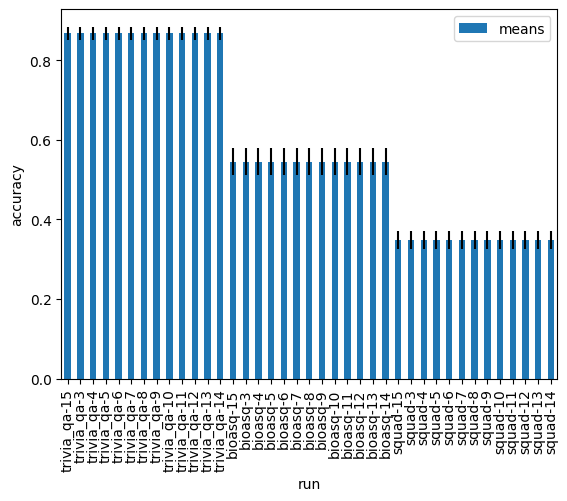

In [11]:
plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run'))
plt.gca().set_ylabel('accuracy')

* 7b largely performs very similar to 70b, usually a little worse (5-10%)
* Only big difference is for trivia-qa, where removing context leads to ~20 percent accuracy hit from ~85 to ~65 (this is not necessarily bad for us though)


In [12]:
metric_names = [
    'AUROC',
    'area_under_thresholded_accuracy',
    'mean_uncertainty',
    'accuracy_at_0.8_answer_fraction',
    'accuracy_at_0.9_answer_fraction',
    'accuracy_at_0.95_answer_fraction'
]

pdfs = {}
for wandb_id in runs:
    results = all_results[wandb_id]
    pdfs[wandb_id] = get_uncertainty_df(results)

runids = list(pdfs.keys())

tmp = pd.DataFrame(pdfs[runids[0]])
tmp['run'] = runs[runids[0]]
tmp['wandb_id'] = runids[0]

for runid in runids[1:]:
    tmp2 = pd.DataFrame(pdfs[runid])
    tmp2['run'] = runs[runid]
    tmp2['wandb_id'] = runid

    tmp = pd.concat([tmp, tmp2])

all_runs = tmp.reset_index()

all_runs['num_generations'] = all_runs.run.map(lambda x: int(x.split('-')[1]))
all_runs['dataset'] = all_runs.run.map(lambda x: x.split('-')[0])

main_methods = ['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy', 'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao', 'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao']

In [13]:
# fig, axes_2d = plt.subplots(len(metric_names), len(runs), sharex=True, figsize=(15, 15), dpi=100)
# # fig.suptitle(config['dataset']['value'] + ' '+ plt.gca().get_title())
# for k, (name, axes) in enumerate(zip(list(metric_names), axes_2d)):

#     for i, (ax, wandb_id) in enumerate(zip(axes, runs)):
#         plot_bar_uncertainty(pdfs[wandb_id], name, ax=ax)

#         if i == 0:
#             ax.set_ylabel(name, fontsize=8, rotation=0, ha='right')

#         if k == 0:
#             ax.set_title(runs[wandb_id])


# plt.tight_layout()
# plt.subplots_adjust(wspace=0.1, hspace=0.1)

In [14]:
# df2 = deepcopy(all_runs)
# df2 = df2[all_runs.method == 'cluster_assignment_entropy']
# df2 = df2.sort_values(['run', 'metric'])

# fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

# g = sns.barplot(
#     x="metric",       # x variable name
#     y="means",       # y variable name
#     hue="run",  # group variable name
#     data=df2,     # dataframe to plot
#     ax=ax,
# )

# # https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
# x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
# y_coords = [p.get_height() for p in ax.patches]

# for kind in ['low', 'high']:
#     tmp = df2[kind].values
#     ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
#     ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
# ax.grid(zorder=-100, alpha=0.2)
# # ax.set_ylim(0.3, 1)
# plt.tight_layout()

In [15]:
# df2 = deepcopy(all_runs)
# df2 = df2[all_runs.method == 'semantic_entropy_sum_cmean']
# df2 = df2[all_runs.metric != 'mean_uncertainty']

# df2 = df2.sort_values(['run', 'metric'])

# fig, ax = plt.subplots(1, 1, figsize=(10, 8), sharey=True, dpi=100)

# g = sns.barplot(
#     x="metric",       # x variable name
#     y="means",       # y variable name
#     hue="run",  # group variable name
#     data=df2,     # dataframe to plot
#     ax=ax,
# )

# # https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
# x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
# y_coords = [p.get_height() for p in ax.patches]

# for kind in ['low', 'high']:
#     tmp = df2[kind].values
#     ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
#     ax.scatter(x_coords[:-len(df2.run.unique())], tmp, c='red', marker='x')
# ax.grid(zorder=-100, alpha=0.2)
# # ax.set_ylim(0.3, 1)
# plt.tight_layout()

In [16]:
# df2 = deepcopy(all_runs)
# df2 = df2[df2.metric == 'AUROC']

# df2 = df2[df2.method.map(lambda x: x in main_methods)]
# df2 = df2.sort_values(['method', 'run'])

# fig, ax = plt.subplots(1, 1, figsize=(15, 8), sharey=True, dpi=100)

# g = sns.barplot(
#     x="run",       # x variable name
#     y="means",       # y variable name
#     hue="method",  # group variable name
#     data=df2,     # dataframe to plot
#     ax=ax,
# )

# # https://stackoverflow.com/questions/72352491/how-to-plot-errorbars-on-seaborn-barplot
# x_coords = [p.get_x() + 0.5 * p.get_width() for p in ax.patches]
# y_coords = [p.get_height() for p in ax.patches]

# for kind in ['low', 'high']:
#     tmp = df2[kind].values
#     ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
#     ax.scatter(x_coords[:-len(df2.method.unique())], tmp, c='red', marker='x')
# ax.grid(zorder=-100, alpha=0.2)
# # ax.set_ylim(0.3, 1)
# plt.tight_layout()

text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)


Text(0.5, 80.7222222222222, 'Number of generations')

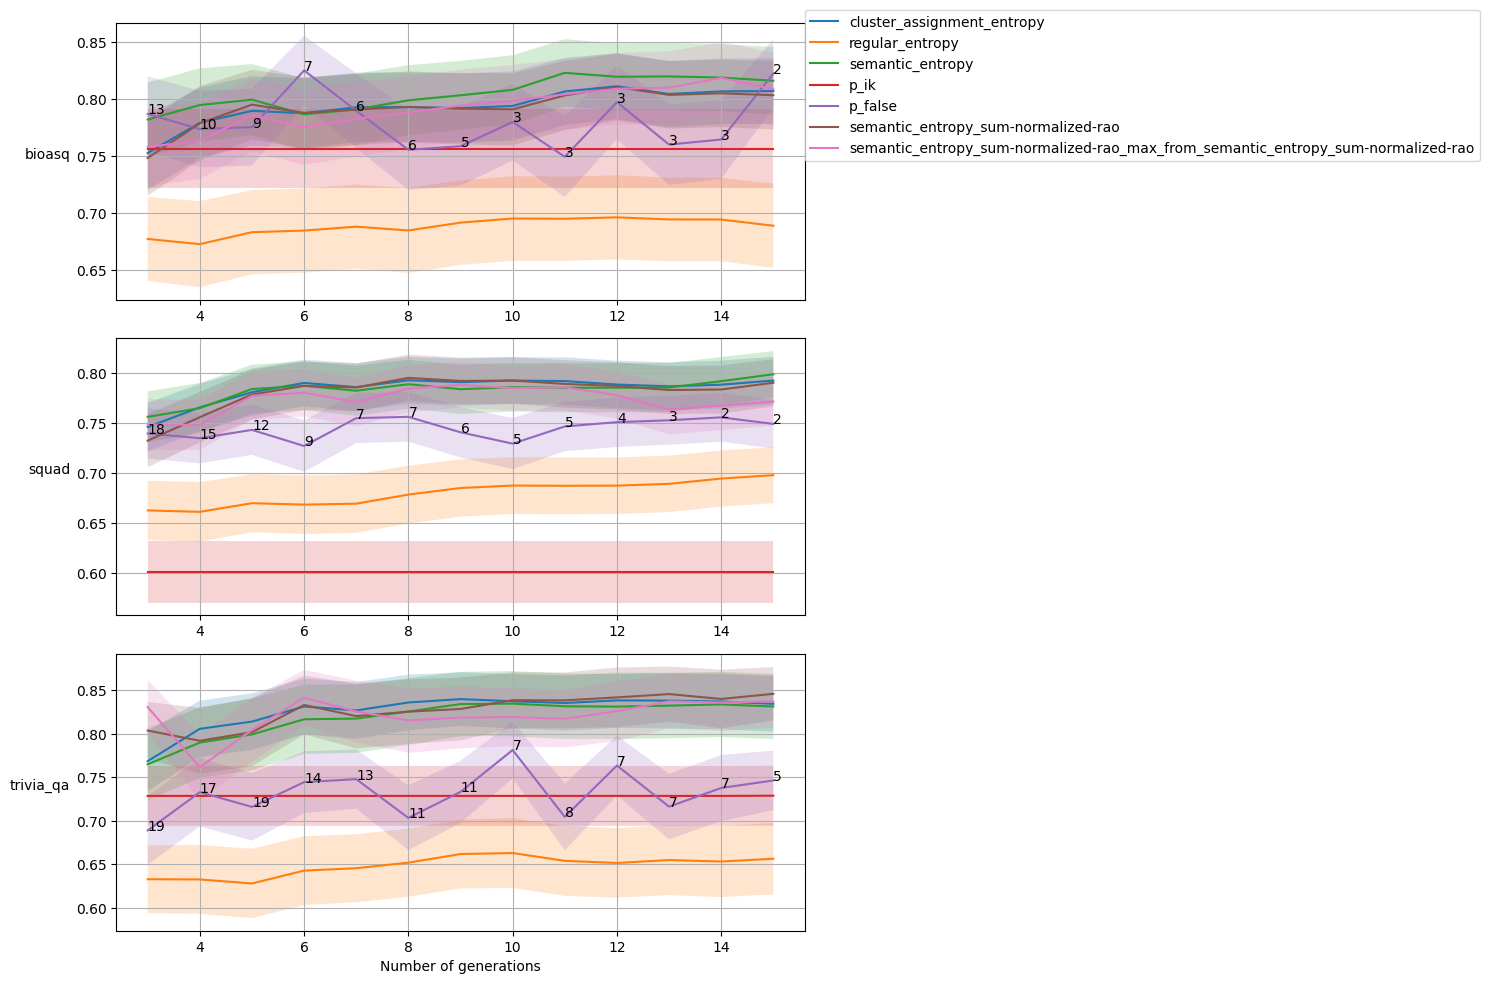

In [17]:
df2 = deepcopy(all_runs)
df2 = df2[df2.metric == 'AUROC']
# df2 = df2[df2.metric == 'area_under_thresholded_accuracy']

fig, axes = plt.subplots(df2.dataset.nunique(), figsize=(15, 10))

if df2.dataset.nunique() == 1:
    axes = [axes]

methods = main_methods

for ax, (dataset, gdf) in  zip(axes, df2.groupby('dataset')):
    ax.set_ylabel(dataset, rotation=0, ha='right')
    ax.grid()
    for m, method in enumerate(methods):
        df3 = gdf[gdf.method == method]
        x, y, h, l = df3.num_generations.values, df3.means.values, df3.low.values, df3.high.values
        idxs = np.argsort(x)
        x, y, h, l = x[idxs], y[idxs], h[idxs], l[idxs]
        ax.plot(x, y, label=method)
        ax.fill_between(x, h, l, alpha=0.2, zorder=-10)
        if method == 'p_false':
            ids = df3.wandb_id.values[idxs]
            if dataset == 'squad':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            elif dataset == 'trivia_qa':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 5})['value'] for wid in ids]
            elif dataset == 'bioasq':
                num_p_true = [all_configs[wid].get('p_true_num_fewshot', {'value': 2})['value'] for wid in ids]
            else:
                raise
            for xpos, ypos, text in zip(x, y, num_p_true):
                ax.text(xpos, ypos, text)

axes[0].legend(loc=(1, 0.5))
print("text for p_true gives number of in-context demonstrations for p_true (decreases with num_generations due to token limit)")
plt.tight_layout()
axes[-1].set_xlabel('Number of generations')

In [18]:
tmp = all_runs.set_index('metric').loc['AUROC']
tmp = tmp[tmp.method.map(lambda x: 'UNANSWERABLE' not in x)]

In [19]:
tmp.groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high,num_generations
method,,,,
semantic_entropy_sum-normalized,0.807783,0.778127,0.837439,9.0
semantic_entropy,0.802153,0.770896,0.833410,9.0
semantic_entropy_sum-normalized_max_from_semantic_entropy_sum-normalized,0.801453,0.772075,0.830830,9.0
cluster_assignment_entropy,0.801333,0.772679,0.829988,9.0
semantic_entropy_sum-normalized-rao,0.800239,0.770389,0.830088,9.0
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.795260,0.765241,0.825280,9.0
semantic_entropy_max_from_semantic_entropy,0.794627,0.764178,0.825076,9.0
semantic_entropy_sum_sum-normalized_max_from_semantic_entropy_sum_sum-normalized,0.781388,0.750271,0.812504,9.0
semantic_entropy_sum_sum-normalized,0.775569,0.743603,0.807536,9.0


In [20]:
tmp[tmp.run.map(lambda x: '70b' in x)].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high,num_generations
method,,,,


In [21]:
tmp[tmp.run.map(lambda x: '7b' in x)].groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high,num_generations
method,,,,


In [22]:
tmp.set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)

,means,low,high,num_generations
method,,,,
semantic_entropy,0.802153,0.770896,0.833410,9.0
cluster_assignment_entropy,0.801333,0.772679,0.829988,9.0
semantic_entropy_sum-normalized-rao,0.800239,0.770389,0.830088,9.0
semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao,0.795260,0.765241,0.825280,9.0
p_false,0.752198,0.720538,0.783858,9.0
p_ik,0.695188,0.661857,0.728520,9.0
regular_entropy,0.672111,0.636898,0.707324,9.0


In [23]:
tmp[tmp.run.map(lambda x: '7b' in x)].set_index('method').loc[main_methods].reset_index().groupby('method').mean('means').sort_values('means', ascending=False)

KeyError: "None of [Index(['cluster_assignment_entropy', 'regular_entropy', 'semantic_entropy',\n       'p_ik', 'p_false', 'semantic_entropy_sum-normalized-rao',\n       'semantic_entropy_sum-normalized-rao_max_from_semantic_entropy_sum-normalized-rao'],\n      dtype='object', name='method')] are in the [index]"